In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

np.random.seed(123)
tf.random.set_seed(123)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:

CLASS_NAMES = [
    "Speed Limit 30",
    "Speed Limit 60",
    "Speed Limit 90",
    "Stop",
    "No Entry",
    "Yield",
    "Pedestrian Crossing",
    "No Overtaking"
]

N_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 32
IMAGES_PER_CLASS = 250

print("Classes:", N_CLASSES)
print("Images per class:", IMAGES_PER_CLASS)

Classes: 8
Images per class: 250


In [3]:

def generate_sign_images(class_id, count):
    images = np.random.uniform(
        0.0, 0.12, size=(count, IMG_SIZE, IMG_SIZE, 3)
    ).astype(np.float32)

    yy, xx = np.ogrid[:IMG_SIZE, :IMG_SIZE]
    center = (IMG_SIZE - 1) / 2

    for i in range(count):
        img = images[i]

        if class_id == 0:
            img[:, 5:11, 0] += 0.85

        elif class_id == 1:
            img[:, 21:27, 1] += 0.85

        elif class_id == 2:
            img[21:27, :, 2] += 0.85

        elif class_id == 3:
            mask = (xx-center)**2 + (yy-center)**2 <= 10**2
            img[mask] = [0.95, 0.05, 0.05]

        elif class_id == 4:
            img[6:26, 6:26] = [0.92, 0.92, 0.92]
            img[10:22, 10:22] = [0.95, 0.05, 0.05]

        elif class_id == 5:
            for row in range(6, 26):
                width = max(1, row - 5)
                start = max(0, center - width / 2)
                end = min(IMG_SIZE, center + width / 2)
                img[row, int(start):int(end)] = [0.95, 0.85, 0.05]

        elif class_id == 6:
            img[10:14, :] = [0.95, 0.95, 0.95]
            img[18:22, :] = [0.95, 0.95, 0.95]
            img[:, 14:18] = [0.95, 0.95, 0.95]

        elif class_id == 7:
            for d in range(5, 27):
                if d + 2 < IMG_SIZE:
                    img[d, d-2:d+2] = [0.95, 0.95, 0.95]
                    img[d, 27-d:29-d] = [0.95, 0.95, 0.95]

        images[i] = np.clip(img, 0, 1)

    return images


X_parts = []
y_parts = []

for class_id in range(N_CLASSES):
    X_class = generate_sign_images(class_id, IMAGES_PER_CLASS)
    y_class = np.full(IMAGES_PER_CLASS, class_id)

    X_parts.append(X_class)
    y_parts.append(y_class)

X = np.concatenate(X_parts).astype("float32")
y = np.concatenate(y_parts)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)
print("Number of Classes:", N_CLASSES)

Dataset Shape: (2000, 32, 32, 3)
Labels Shape: (2000,)
Number of Classes: 8


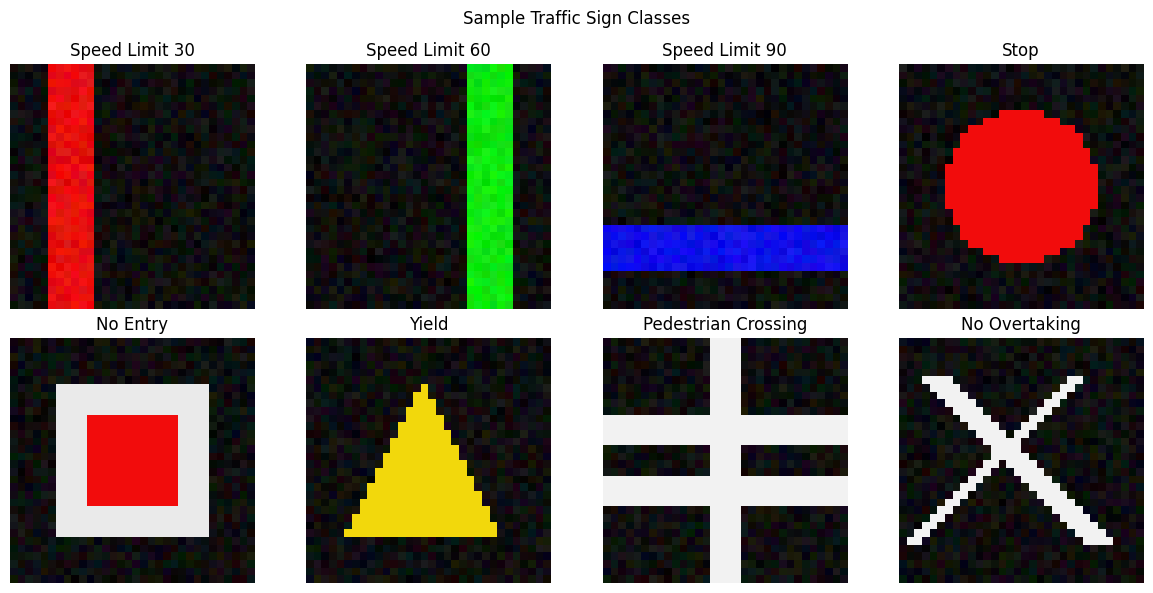

In [4]:

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for class_id, ax in enumerate(axes.flat):
    ax.imshow(X[class_id * IMAGES_PER_CLASS])
    ax.set_title(CLASS_NAMES[class_id])
    ax.axis("off")

plt.suptitle("Sample Traffic Sign Classes")
plt.tight_layout()
plt.show()

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

y_train_cat = to_categorical(y_train, N_CLASSES)
y_test_cat = to_categorical(y_test, N_CLASSES)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1600, 32, 32, 3)
Testing Data: (400, 32, 32, 3)


In [6]:

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(N_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,552 (1.36 MB)

 Trainable params: 356,552 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:

history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.20,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.8961 - loss: 0.4077 - val_accuracy: 1.0000 - val_loss: 4.6502e-04
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 1.2703e-05
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 1.0000 - loss: 1.9352e-04 - val_accuracy: 1.0000 - val_loss: 4.5415e-06
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 1.0000 - loss: 1.2987e-04 - val_accuracy: 1.0000 - val_loss: 2.3663e-06
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 1.0000 - loss: 1.0994e-04 - val_accuracy: 1.0000 - val_loss: 1.5810e-06
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 1.0000 - loss: 5.2664e-05 - val_accuracy: 1.0000 - val_loss: 7.9498e-07
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 1.0000 - loss: 4.7625e-05 - val_accuracy: 1.0000 - val_loss: 4.4592e-07
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accurac

In [8]:

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Test Loss:", round(float(test_loss), 4))
print("Test Accuracy:", round(float(test_accuracy), 4))

Test Loss: 0.0
Test Accuracy: 1.0


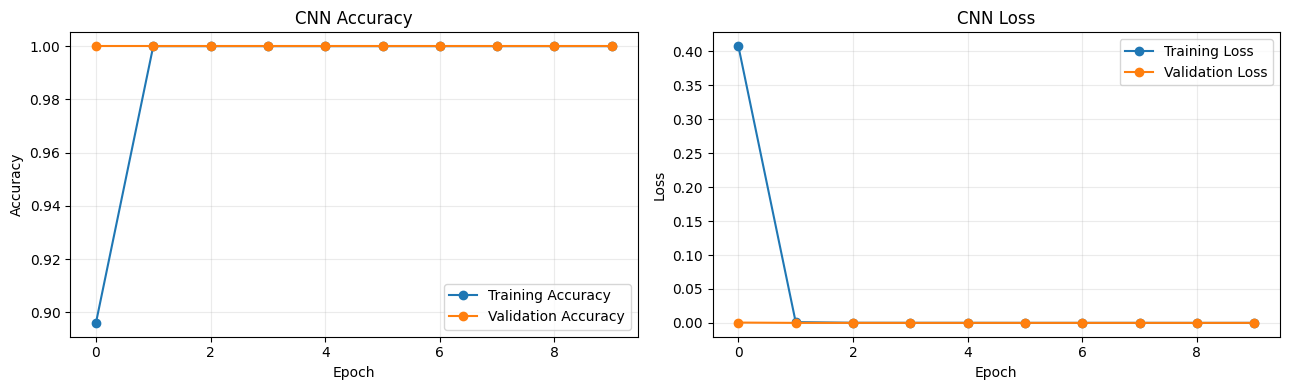

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["accuracy"], marker="o", label="Training Accuracy")
axes[0].plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
axes[0].set_title("CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(history.history["loss"], marker="o", label="Training Loss")
axes[1].plot(history.history["val_loss"], marker="o", label="Validation Loss")
axes[1].set_title("CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

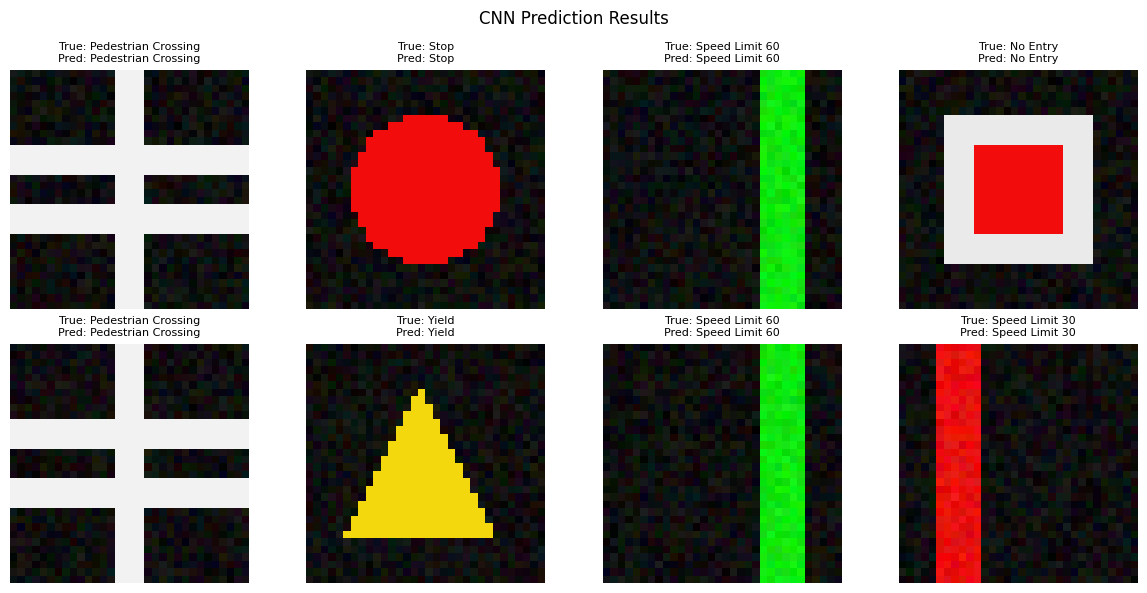

In [10]:

sample_count = 8
sample_images = X_test[:sample_count]
sample_true = y_test[:sample_count]
sample_prob = model.predict(sample_images, verbose=0)
sample_pred = np.argmax(sample_prob, axis=1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i])
    ax.set_title(
        f"True: {CLASS_NAMES[sample_true[i]]}\nPred: {CLASS_NAMES[sample_pred[i]]}",
        fontsize=8
    )
    ax.axis("off")

plt.suptitle("CNN Prediction Results")
plt.tight_layout()
plt.show()